# KCs MOT simulation with pyLCP package 

ref: https://python-laser-cooling-physics.readthedocs.io/en/latest/examples.html 

In [1]:
import pylcp
import pathos
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import iqr
from pylcp.common import progressBar
import lmfit

## Optical molasses 

`pyLCP` requires Hanmiltonian, lasers, magnetic field for every simulation

here we are following heurisitc two level system example at https://python-laser-cooling-physics.readthedocs.io/en/latest/examples/molasses/00_two_level_1D_molasses.html

In [2]:
mass = 200

# method to return laser 
def return_lasers(delta, s):
    return pylcp.laserBeams([
        {
            'kvec':np.array([1,0,0]),
            'pol': np.array([0,1,0]),    #pi polarized light
            'pol_coord': 'spherical',
            'delta': delta,
            's': s
        },
        {
            'kvec':np.array([-1,0,0]),
            'pol': np.array([0,1,0]),    #pi polarized light
            'pol_coord': 'spherical',
            'delta': delta,
            's': s
        }
    ], beam_type=pylcp.infinitePlaneWaveBeam)

#two level Hamiltonian
def return_hamiltonian(delta):
    Hg = np.array([[0]])
    He = np.array([[-delta]])
    mu_q = np.zeros((3,1,1))
    d_q = np.zeros((3,1,1))
    d_q[1,0,0] = 1
    return pylcp.hamiltonian(Hg, He, mu_q, mu_q, d_q, mass=mass)

hamiltonian = return_hamiltonian(0)

magField = lambda R: np.zeros(R.shape)  # zero field

$H_{int}$ = $-\sum$ `d_q`  $E_{q}$

$H_{zeeman}$ = $-\sum$ `mu_q` $B_{q}$

`delta` : detuning 

`s` = $I/I_{sat}$

Governing equations : OBE (optical bloch eqn), rate equation ? heuristic equantion ?

In [4]:
delta = -2.
s = 1.5

# two counter propagting molasses beams 
laserBeams = return_lasers(delta, s)

# detuning is handled in the laser setup 
hamiltonian = return_hamiltonian(0.)


eqns = {}
eqns['obe'] = pylcp.obe(laserBeams, magField, hamiltonian)
'''
Creates the optical Bloch equations model.
This is the most complete quantum description.
'''


eqns['rateeq'] = pylcp.rateeq(laserBeams, magField, hamiltonian)
                # "import importlib",
                # "import pylcp.integration_tools as integration_tools",
                # "import pylcp.heuristiceq as heuristiceq_module",
                # "",
                # "importlib.reload(integration_tools)",
                # "heuristiceq_module.solve_ivp_random = integration_tools.solve_ivp_random",
                # "",
                # "eqn.set_initial_position_and_velocity(np.zeros(3), np.zeros(3))",
                # "eqn.evolve_motion(",
                # "    [0., 1.],",
                # "    random_recoil=True,",
                # "    max_scatter_probability=0.25,",
                # "    freeze_axis=[False, True, True]",
                # ")",
                # "print('one-atom test passed:', eqn.sol.v[0, -1])"
'''
Creates the rate equations model.
This is a simpler semiclassical/incoherent approximation.
'''

eqns['heuristiceq'] = pylcp.heuristiceq(laserBeams, magField)
'''
Creates the heuristic equations model.
This uses an approximate force model rather than full state evolution.
'''
extra_args = {}
extra_args['obe'] = {'progress_bar':True, 'deltat_tmax':2*np.pi*100, 'deltat_v':4,
                     'itermax':1000, 'rel':1e-4, 'abs':1e-6}
'''
Sets solver options for the OBE calculation:
progress_bar=True: show progress
deltat_tmax: max integration time
deltat_v: velocity stepping parameter
itermax: max iterations
rel, abs: relative and absolute tolerances

'''


extra_args['rateeq'] = {}
extra_args['heuristiceq'] = {}

v = np.arange(-10., 10.1, 0.1)

for key in eqns:
    eqns[key].generate_force_profile(np.zeros((3,) + v.shape),
                                     [v, np.zeros(v.shape), np.zeros(v.shape)],
                                     name='molasses', **extra_args[key])

'''
Computes the force as a function of velocity for each model.
Arguments:
np.zeros((3,) + v.shape): positions, all set to zero
[v, np.zeros(v.shape), np.zeros(v.shape)]: velocity vector with motion only along x
name='molasses': labels the force profile
**extra_args[key]: passes method-specific settings
'''

Completed in 9.02 s.                                               


"\nComputes the force as a function of velocity for each model.\nArguments:\nnp.zeros((3,) + v.shape): positions, all set to zero\n[v, np.zeros(v.shape), np.zeros(v.shape)]: velocity vector with motion only along x\nname='molasses': labels the force profile\n**extra_args[key]: passes method-specific settings\n"

force profile 

<>:9: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:10: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:9: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:10: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\3455683440.py:9: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ax.set_xlabel('$v/(\Gamma/k)$')
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\3455683440.py:10: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will

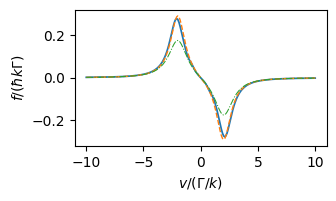

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.25, 2.))
lbls = {'obe':'OBE', 'rateeq':'Rate Eq.', 'heuristiceq':'Heuristic Eq.'}
styles = ['-','--','-.']
for ii, key in enumerate(eqns):
    ax.plot(v, eqns[key].profile['molasses'].F[0], styles[ii],
            label=lbls[key], linewidth=1.25-0.25*ii)
    #ax[1].plot(v, eqn.profile['molasses'].Neq)
#ax.legend(fontsize=7)
ax.set_xlabel('$v/(\Gamma/k)$')
ax.set_ylabel('$f/(\hbar k \Gamma)$')
fig.subplots_adjust(bottom=0.2)

note that the force is positive for negative v and negative for positive v --> Force decelerates atoms

In [16]:
help(eqns['obe'].profile['molasses'])

Help on force_profile in module pylcp.obe object:

class force_profile(pylcp.common.base_force_profile)
 |  force_profile(R, V, laserBeams, hamiltonian)
 |
 |  Optical Bloch equation force profile
 |
 |  The force profile object stores all of the calculated quantities created by
 |  the rateeq.generate_force_profile() method.  It has the following
 |  attributes:
 |
 |  Attributes
 |  ----------
 |  R  : array_like, shape (3, ...)
 |      Positions at which the force profile was calculated.
 |  V : array_like, shape (3, ...)
 |      Velocities at which the force profile was calculated.
 |  F : array_like, shape (3, ...)
 |      Total equilibrium force at position R and velocity V.
 |  f_mag : array_like, shape (3, ...)
 |      Magnetic force at position R and velocity V.
 |  f : dictionary of array_like
 |      The forces due to each laser, indexed by the
 |      manifold the laser addresses.  The dictionary is keyed by the transition
 |      driven, and individual lasers are in the sa

In [ ]:
force profile

extract temperature of many atoms 

recoil by the spontaenous emission --> random walk 

balance between these diffusive heating and cooling where heating (cooling) is velocity increase (decrease)

at this moment, equilibrium temperature can be defined!

integration is key parameter to estimate this random walk. 

the intergration time could be inverse of scattering rate $R$

$R_{sc} = \frac{\Gamma}{2} \frac{s}{1+2s+4\delta^2} $

In [17]:
s = 3
delta = -3

laserBeams = return_lasers(delta, s)
hamiltonian = return_hamiltonian(0.)

eqn = pylcp.heuristiceq(laserBeams, magField, mass=mass)
#eqn = pylcp.rateeq(laserBeams, magField, hamiltonian, include_mag_forces=False)
#eqn = pylcp.obe(laserBeams, magField, hamiltonian)

eqn.set_initial_position_and_velocity(np.array([0., 0., 0.]), np.array([0., 0., 0.]))
if isinstance(eqn, pylcp.rateeq):
    eqn.set_initial_pop_from_equilibrium()
elif isinstance(eqn, pylcp.obe):
    eqn.set_initial_rho_from_rateeq()

N_atom = 96 # Needs to be divisible by chunksize

In [21]:
if hasattr(eqn, 'sol'):
    del eqn.sol

def generate_random_solution(eqn, tmax, rng_seed):
    import numpy as np
    import pylcp.heuristiceq as heuristiceq_module
    import pylcp.integration_tools as integration_tools

    heuristiceq_module.np = np
    heuristiceq_module.solve_ivp_random = integration_tools.solve_ivp_random
    integration_tools.np = np
    # We need to generate random numbers to prevent solutions from being seeded
    # with the same random number.
    eqn.evolve_motion(
        [0., tmax],
        random_recoil=True,
        max_scatter_probability=0.25,
        freeze_axis=[False, True, True],
        rng=np.random.default_rng(rng_seed)
    )

    return eqn.sol.v[0, -1]

chunksize = 4
v_final = []
ss = np.random.SeedSequence(12345) # "It's the same combination as my luggage!"
child_seeds = ss.spawn(N_atom)
progress = progressBar()
for jj in range(int(N_atom/chunksize)):
    with pathos.pools.ProcessPool(nodes=4) as pool:
        v_final += pool.map(
            generate_random_solution,
            chunksize*[eqn],
            chunksize*[10*mass*(1+2*s+4*np.abs(delta)**2)/s],
            child_seeds[jj*chunksize:(jj+1)*chunksize]
        )
    progress.update((jj+1)/int(N_atom/chunksize))

x_fit = np.linspace(-1.1*np.amax(np.abs(v_final)), 1.1*np.amax(np.abs(v_final)), 101)

eqn.generate_force_profile(np.zeros((3,) + x_fit.shape),
                           [x_fit, np.zeros(x_fit.shape), np.zeros(x_fit.shape)],
                            name='molasses');

NameError: name 'np' is not defined

In [19]:
np.abs(1)

np.int64(1)

<>:41: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:42: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:41: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:42: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\3316290787.py:41: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ax.set_xlabel('$\Gamma t$')
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\3316290787.py:42: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will 

Completed in 22:19.                                                 


C:\Users\20141\AppData\Local\Temp\ipykernel_54320\3316290787.py:41: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ax.set_xlabel('$\Gamma t$')
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\3316290787.py:42: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ax.set_ylabel('$v/(\Gamma/k)$');


NameError: name 'x_fit' is not defined

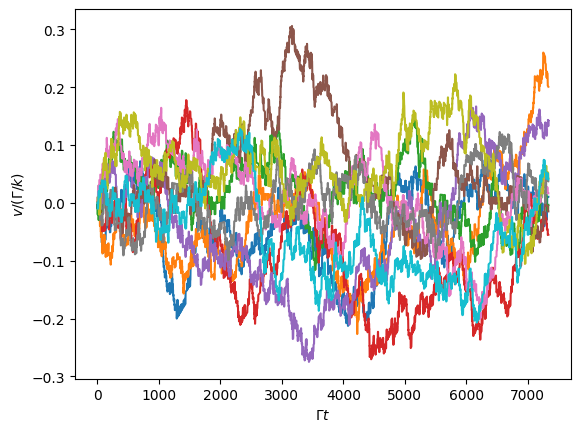

In [6]:
s = 3
delta = -1

laserBeams = return_lasers(delta, s)
hamiltonian = return_hamiltonian(0.)

eqn = pylcp.heuristiceq(laserBeams, magField, mass=mass)
#eqn = pylcp.rateeq(laserBeams, magField, hamiltonian, include_mag_forces=False)
#eqn = pylcp.obe(laserBeams, magField, hamiltonian)

N_atom = 256
v_final = np.zeros((N_atom,))
#num_of_scatters = np.zeros((N_atom,), dtype='int')
#num_of_steps = np.zeros((N_atom,), dtype='int')

fig, ax = plt.subplots(1, 1)
sols = []
progress = progressBar()
for ii in range(N_atom):
    eqn.set_initial_position_and_velocity(np.array([0., 0., 0.]), np.array([0., 0., 0.]))
    if isinstance(eqn, pylcp.rateeq):
        eqn.set_initial_pop_from_equilibrium()
    elif isinstance(eqn, pylcp.obe):
        eqn.set_initial_rho_from_rateeq()

    eqn.evolve_motion([0., 10*mass*(1+2*s+4*np.abs(delta)**2)/s],
                      random_recoil=True,
                      max_scatter_probability=0.25,
                      freeze_axis=[False, True, True])
    progress.update((ii+1.)/N_atom)

    if ii<10:
        ax.plot(eqn.sol.t, eqn.sol.v[0])

    v_final[ii] = eqn.sol.v[0, -1]

    sols.append(eqn.sol)
    #num_of_scatters[ii] = sum(eqn.sol.n_random)
    #num_of_steps[ii] = len(eqn.sol.t)

ax.set_xlabel('$\Gamma t$')
ax.set_ylabel('$v/(\Gamma/k)$');

eqn.generate_force_profile(np.zeros((3,) + x_fit.shape),
                           [x_fit, np.zeros(x_fit.shape), np.zeros(x_fit.shape)],
                            name='molasses')

In [7]:
x_fit = np.linspace(-1.1*np.amax(np.abs(v_final)), 1.1*np.amax(np.abs(v_final)), 101)
eqn.generate_force_profile(np.zeros((3,) + x_fit.shape),
                           [x_fit, np.zeros(x_fit.shape), np.zeros(x_fit.shape)],
                            name='molasses')

<>:51: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:53: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:51: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:53: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\2713077403.py:51: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ax.set_xlabel('$v_{\\rm final}/(\Gamma/k)$');
C:\Users\20141\AppData\Local\Temp\ipykernel_54320\2713077403.py:53: SyntaxWarning: "\h" is an invalid escape sequence. Su

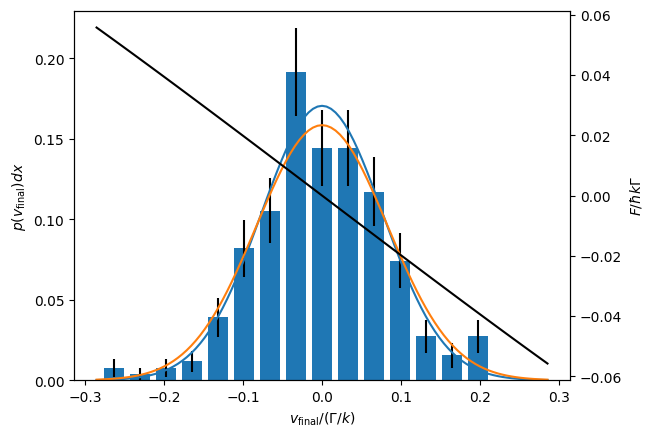

In [8]:
#print(2*np.std(v_final)**2*mass)
def normaldist(x, mu, sigma, dx):
    # Gaussian probability distribution function
    # probability of landing in a bin of width dx is p(x)dx
    return dx/sigma/np.sqrt(2*np.pi)*np.exp(-(x-mu)**2/2/sigma**2)

def lett_temperature(s, delta):
    """
    Returns the ratio of the expected temperature relative to the "bare" Doppler temperature.
    """
    return 0.5*(1+2*s+4*delta**2)/2/np.abs(delta)

def fit_vfinal(v_final, N_atom):
    dx = 2*iqr(v_final)/N_atom**(1/3)
    xb = np.arange(dx/2, 1.1*np.amax(np.abs(v_final)), dx)
    xb = np.concatenate((-xb[::-1], xb))

    x = xb[:-1] + np.diff(xb)/2
    y = np.histogram(v_final, bins=xb)[0]/N_atom #Probability of an atom landing in this bin.'

    ok = (y>0)
    weights = np.zeros(ok.shape)
    weights[ok] = 1./np.sqrt(y[ok]/N_atom)
    model = lmfit.Model(normaldist)
    params = model.make_params()
    params['dx'].value = dx # bin width, probability of landing in the bin is p(x) dx
    params['dx'].vary = False
    params['mu'].value = 0.
    params['mu'].vary = False
    params['sigma'].value = np.std(v_final)

    result = model.fit(y[ok], params, x=x[ok], weights=weights[ok])

    return result, x, y, dx

result, x, y, dx = fit_vfinal(v_final, N_atom)

fig, ax = plt.subplots(1, 1)

ax.bar(x, y, width=0.8*dx, yerr=np.sqrt(y/N_atom)) #Poissonian error

x_fit = np.linspace(-1.1*np.amax(np.abs(v_final)), 1.1*np.amax(np.abs(v_final)), 101)

ax.plot(x_fit, result.eval(x=x_fit))
ax.plot(x_fit, normaldist(x_fit, 0, np.sqrt(lett_temperature(s, delta)/2/mass), dx))

ax_twin = ax.twinx()
ax_twin.plot(x_fit, eqn.profile['molasses'].F[0], 'k-')

ax.set_ylabel('$p(v_{\\rm final}) dx$')
ax.set_xlabel('$v_{\\rm final}/(\Gamma/k)$');

ax_twin.set_ylabel('$F/\hbar k \Gamma$');

In [9]:
result

standard deviation of the velocity distribution is temperature 


$$\sigma_v^2 = \frac{k_B T}{m}$$